In [29]:
# importing necessary libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split,StratifiedKFold,GridSearchCV,RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
# loading the data 
df = pd.read_csv("../data/processed/data.csv",sep=",")
df.head()

,BMI,Age,Income,PhysicalHealth,GeneralHealth,Education,MentalHealth,HighBp,HighCholesterol,Fruits,Smoke100,Diabetes
0,40.18,9.0,3.0,15.0,1.0,4.0,18.0,1.0,1.0,0.0,1.0,0
1,25.09,7.0,1.0,0.0,3.0,6.0,0.0,0.0,0.0,0.0,1.0,0
2,22.04,11.0,NaN,15.0,2.0,4.0,0.0,0.0,1.0,NaN,NaN,0
3,28.19,9.0,8.0,30.0,1.0,4.0,30.0,1.0,1.0,1.0,0.0,0
4,24.37,9.0,NaN,20.0,1.0,5.0,0.0,0.0,0.0,NaN,0.0,0


In [3]:
# defining features, target variable and spliting into train and test sets 
X = df.drop(columns="Diabetes")
y = df["Diabetes"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1, stratify=y)

In [4]:
# defining the feature datatype
continuous = ["BMI","MentalHealth","PhysicalHealth"]
binary = ["HighBp","HighCholesterol","Smoke100","Fruits"]
ordinal = ["GeneralHealth","Age","Education","Income"]

In [5]:
# Transformers by datatype

# Continuous transformer 
continuous_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

# Binary transformer 
binary_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent"))
])

# Ordinal transformer
ordinal_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(transformers=[
    ("continuous",continuous_transformer,continuous),
    ("binary",binary_transformer,binary),
    ("ordinal",ordinal_transformer,ordinal)
],remainder="passthrough")

In [6]:
# imblearn pipeline here to handle the SMOTE fit_resample phase

# Logistic Regression pipeline 
lr_pipeline = ImbPipeline(steps=[
    ("preprocessor",preprocessor),
    ("smote",SMOTE(random_state=1)),
    ("lr",LogisticRegression(solver="saga", random_state=1))
])
# Random Forest pipeline
rf_pipeline = ImbPipeline(steps=[
    ("preprocessor",preprocessor),
    ("smote",SMOTE(random_state=1)),
    ("rf",RandomForestClassifier(random_state=1))
])
# XGBOOST pipeline
xgb_pipeline = ImbPipeline(steps=[
    ("preprocessor",preprocessor),
    ("smote",SMOTE(random_state=1)),
    ("xgb",XGBClassifier(eval_metric="logloss", random_state=1))
])


In [7]:
# Parameters for  hyperparameter optimizers 

# Logistic regression parameters grid
lr_param_grid = {
    "lr__l1_ratio": [0.0, 1.0],
    "lr__C": [0.01, 0.1, 1, 10],
    "lr__max_iter": [500, 1000, 2000]
}

# Random forest hyperparameter distributions 
rf_param_dist = {
    "rf__n_estimators": [100, 200, 300],
    "rf__max_depth": [5, 10, 20, None],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4]
}

# XGBOOST hyperparameter distributions 
xgb_param_dist = {
    "xgb__n_estimators": [100, 200, 300],
    "xgb__max_depth": [3, 5, 7, 9],
    "xgb__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "xgb__min_child_weight":[1, 3, 5],
    "xgb__subsample": [0.6, 0.8, 1.0]
}

In [8]:
# Stratified K-Fold to maintain class balance across folds
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

In [9]:
# best parameter search Logistic regression 
lr_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=2
)

lr_search.fit(X_train,y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END .....lr__C=0.01, lr__l1_ratio=0.0, lr__max_iter=500; total time=  18.6s
[CV] END .....lr__C=0.01, lr__l1_ratio=0.0, lr__max_iter=500; total time=  19.3s
[CV] END .....lr__C=0.01, lr__l1_ratio=0.0, lr__max_iter=500; total time=  22.7s
[CV] END .....lr__C=0.01, lr__l1_ratio=0.0, lr__max_iter=500; total time=  23.2s
[CV] END .....lr__C=0.01, lr__l1_ratio=0.0, lr__max_iter=500; total time=  19.1s
[CV] END ....lr__C=0.01, lr__l1_ratio=0.0, lr__max_iter=1000; total time=  19.8s
[CV] END ....lr__C=0.01, lr__l1_ratio=0.0, lr__max_iter=1000; total time=  18.8s
[CV] END ....lr__C=0.01, lr__l1_ratio=0.0, lr__max_iter=1000; total time=  21.3s
[CV] END ....lr__C=0.01, lr__l1_ratio=0.0, lr__max_iter=1000; total time=  19.1s
[CV] END ....lr__C=0.01, lr__l1_ratio=0.0, lr__max_iter=1000; total time=  20.7s
[CV] END ....lr__C=0.01, lr__l1_ratio=0.0, lr__max_iter=2000; total time=  19.0s
[CV] END ....lr__C=0.01, lr__l1_ratio=0.0, lr__

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lr__C': [0.01, 0.1, ...], 'lr__l1_ratio': [0.0, 1.0], 'lr__max_iter': [500, 1000, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_exampl

In [31]:
print(f"Best Parameters: {lr_search.best_params_}")
lr_model = lr_search.best_estimator_
# model's best AUC score 
lr_score = lr_search.best_score_
print(f"Best AUC Score: {lr_score}")


Best Parameters: {'lr__C': 0.01, 'lr__l1_ratio': 0.0, 'lr__max_iter': 500}
Best AUC Score: 0.8248387638544974


--- Logistic Regression CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.95      0.73      0.83     72893
           1       0.31      0.77      0.44     11436

    accuracy                           0.73     84329
   macro avg       0.63      0.75      0.63     84329
weighted avg       0.86      0.73      0.77     84329



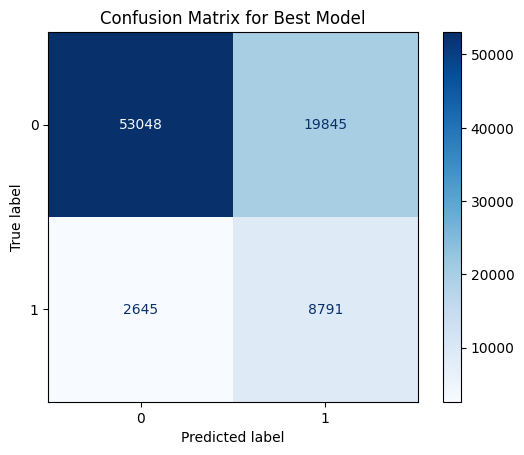

In [24]:
#  Logistic Regression model  evaluation metrics
lr_predictions =  lr_model.predict(X_test)

print("--- Logistic Regression CLASSIFICATION REPORT ---")
print(classification_report(y_true=y_test, y_pred=lr_predictions))

lr_cm = confusion_matrix(y_true=y_test, y_pred=lr_predictions)
lr_disp = ConfusionMatrixDisplay(confusion_matrix=lr_cm, display_labels=lr_model.classes_)

lr_disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix for Best Model")
plt.show()

In [21]:
# best parameter search Random Forest
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=2,
    random_state=1
)
rf_search.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END rf__max_depth=None, rf__min_samples_leaf=4, rf__min_samples_split=2, rf__n_estimators=200; total time= 6.9min
[CV] END rf__max_depth=None, rf__min_samples_leaf=4, rf__min_samples_split=2, rf__n_estimators=200; total time= 6.9min
[CV] END rf__max_depth=None, rf__min_samples_leaf=4, rf__min_samples_split=2, rf__n_estimators=200; total time= 6.9min
[CV] END rf__max_depth=None, rf__min_samples_leaf=4, rf__min_samples_split=2, rf__n_estimators=200; total time= 7.7min
[CV] END rf__max_depth=None, rf__min_samples_leaf=2, rf__min_samples_split=2, rf__n_estimators=100; total time= 3.8min
[CV] END rf__max_depth=None, rf__min_samples_leaf=2, rf__min_samples_split=2, rf__n_estimators=100; total time= 3.9min
[CV] END rf__max_depth=None, rf__min_samples_leaf=2, rf__min_samples_split=2, rf__n_estimators=100; total time= 4.4min
[CV] END rf__max_depth=None, rf__min_samples_leaf=4, rf__min_samples_split=2, rf__n_estimators=200; total 

/home/heisanselem/Documents/Programing/diabetes-risk-predictor/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END rf__max_depth=None, rf__min_samples_leaf=2, rf__min_samples_split=2, rf__n_estimators=100; total time= 4.7min
[CV] END rf__max_depth=None, rf__min_samples_leaf=2, rf__min_samples_split=2, rf__n_estimators=300; total time=13.2min
[CV] END rf__max_depth=None, rf__min_samples_leaf=2, rf__min_samples_split=2, rf__n_estimators=300; total time=11.9min
[CV] END rf__max_depth=None, rf__min_samples_leaf=2, rf__min_samples_split=2, rf__n_estimators=300; total time=13.8min
[CV] END rf__max_depth=None, rf__min_samples_leaf=2, rf__min_samples_split=2, rf__n_estimators=300; total time=12.8min
[CV] END rf__max_depth=None, rf__min_samples_leaf=1, rf__min_samples_split=10, rf__n_estimators=300; total time=10.7min
[CV] END rf__max_depth=None, rf__min_samples_leaf=2, rf__min_samples_split=2, rf__n_estimators=300; total time=13.6min
[CV] END rf__max_depth=None, rf__min_samples_leaf=1, rf__min_samples_split=10, rf__n_estimators=300; total time=10.5min
[CV] END rf__max_depth=None, rf__min_samples_l

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'rf__max_depth': [5, 10, ...], 'rf__min_samples_leaf': [1, 2, ...], 'rf__min_samples_split': [2, 5, ...], 'rf__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",1
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``r

In [33]:
print(f"Best Parameters: {rf_search.best_params_}")
rf_model = rf_search.best_estimator_
# model's best AUC score 
rf_score = rf_search.best_score_
print(f"Best AUC Score: {rf_score}")


Best Parameters: {'rf__n_estimators': 100, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 4, 'rf__max_depth': 10}
Best AUC Score: 0.8241083756786697


--- Random Forest CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.94      0.79      0.86     72893
           1       0.34      0.68      0.45     11436

    accuracy                           0.78     84329
   macro avg       0.64      0.73      0.66     84329
weighted avg       0.86      0.78      0.80     84329



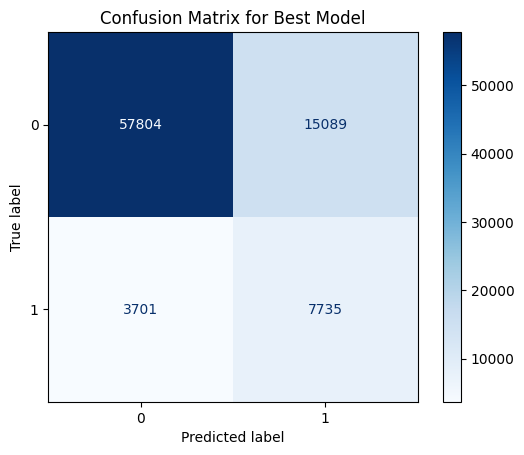

In [25]:
#  Random Forest model  evaluation metrics
rf_predictions =  rf_model.predict(X_test)

print("--- Random Forest CLASSIFICATION REPORT ---")
print(classification_report(y_true=y_test, y_pred=rf_predictions))

rf_cm = confusion_matrix(y_true=y_test, y_pred=rf_predictions)
rf_disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=rf_model.classes_)

rf_disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix for Best Model")
plt.show()

In [26]:
# best parameter search XGBClassifier
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline, 
    param_distributions=xgb_param_dist,
    cv=cv_strategy,       
    scoring='roc_auc',      
    n_jobs=-1,             
    verbose=2,             
    random_state=1
)
xgb_search.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END xgb__learning_rate=0.1, xgb__max_depth=7, xgb__min_child_weight=5, xgb__n_estimators=200, xgb__subsample=0.8; total time=  42.4s
[CV] END xgb__learning_rate=0.1, xgb__max_depth=7, xgb__min_child_weight=5, xgb__n_estimators=200, xgb__subsample=0.8; total time=  43.7s
[CV] END xgb__learning_rate=0.1, xgb__max_depth=7, xgb__min_child_weight=5, xgb__n_estimators=200, xgb__subsample=0.8; total time=  46.9s
[CV] END xgb__learning_rate=0.1, xgb__max_depth=7, xgb__min_child_weight=5, xgb__n_estimators=200, xgb__subsample=0.8; total time=  47.8s
[CV] END xgb__learning_rate=0.2, xgb__max_depth=5, xgb__min_child_weight=3, xgb__n_estimators=200, xgb__subsample=1.0; total time=  36.0s
[CV] END xgb__learning_rate=0.2, xgb__max_depth=5, xgb__min_child_weight=3, xgb__n_estimators=200, xgb__subsample=1.0; total time=  35.3s
[CV] END xgb__learning_rate=0.2, xgb__max_depth=5, xgb__min_child_weight=3, xgb__n_estimators=200, xgb__subsamp

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'xgb__learning_rate': [0.01, 0.05, ...], 'xgb__max_depth': [3, 5, ...], 'xgb__min_child_weight': [1, 3, ...], 'xgb__n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",1
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best es

In [34]:
print(f"Best Parameters: {xgb_search.best_params_}")
xgb_model = xgb_search.best_estimator_
# model's best AUC score 
xgb_score = xgb_search.best_score_
print(f"Best AUC Score: {xgb_score}")

Best Parameters: {'xgb__subsample': 1.0, 'xgb__n_estimators': 100, 'xgb__min_child_weight': 3, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.05}
Best AUC Score: 0.8261434184151752


--- XGBoost CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.94      0.78      0.85     72893
           1       0.33      0.71      0.45     11436

    accuracy                           0.77     84329
   macro avg       0.64      0.74      0.65     84329
weighted avg       0.86      0.77      0.80     84329



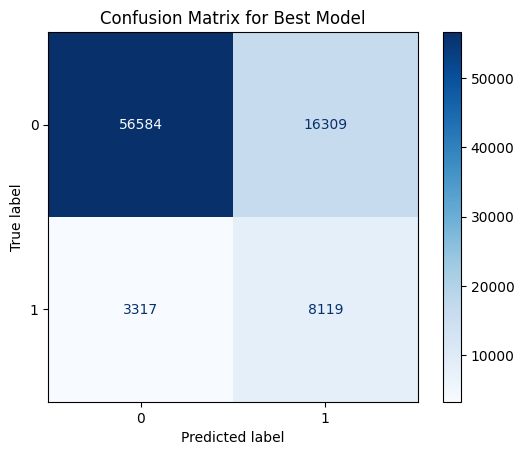

In [28]:
#  XGBClassifier model  evaluation metrics
xgb_predictions =  xgb_model.predict(X_test)

print("--- XGBoost CLASSIFICATION REPORT ---")
print(classification_report(y_true=y_test, y_pred=xgb_predictions))

xgb_cm = confusion_matrix(y_true=y_test, y_pred=xgb_predictions)
xgb_disp = ConfusionMatrixDisplay(confusion_matrix=xgb_cm, display_labels=xgb_model.classes_)

xgb_disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix for Best Model")
plt.show()

**The AUC scores of the 3 models are nearly identical (from 0.824 to 0.826) and an  AUC of apprximatey 0.82 means all three models have the exact same fundamental ability to separate the healthy patients from the high-risk patients.**

**Now the question becomes, Out of all the people who actually have diabetes risk, what percentage did my model successfully catch?.This of course is a question which the recall metric answers and when we look at the recall distribution of the 3 models , Logistic Regression Catches 77% of risk cases, XGBoost Catches 71% of risk cases,and Random Forest Catches 68% of risk cases.**

**To understand the impact this has on the real world , lets observe our support (11,436 test cases) in the classification report for diabetes risk.**

**Logistic Regression misses 23% of them, approximately 2,630 patients would leave thinking they are healthy.XGBoost misses 29% of them, approximately 3,316 patients would leave thinking they are healthy. Random Forest misses 32% of them , approximately  3,659 patients would leave  thinking they are healthy.**

**We can see the difference in the number of patients at risk of diabetes that are not noticed.**

**Although the precision of the models are quite low , we are more interested in the recall of our model since our false negatives is very expensive than our false positives (ie. it would be worse  for our model to predict wrongly a diabetic as non diabetic  than a non diabetic as diabetic ).**

**Based on these metrics and evaluations, i choose the Logistic regression model as the best model**

In [36]:
# Model serialization for deployment
import joblib
joblib.dump(lr_model, '../app/artifacts/v1_model.pkl')

['../app/artifacts/v1_model.pkl']